# Repeat-to-repeat variability: one mouse, one experiment type, one condition

Scratch notebook. Pulls **all** single-trial repeats of one (mouse, experiment type, condition), as
EDGAR sees them (baseline-normalised rate via `neural_data.build_cv_samples`; train and test
trials are concatenated, so every repeat is here). Edit the parameters cell, then plot away.

Add to git for now - do not add to the main branch.

In [111]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WC = Path.cwd().resolve()
while not (WC / "data_loader" / "neural_data.py").exists():   # works from scripts/ or repo root
    WC = WC.parent if WC.parent != WC else sys.exit("run from inside projects/wilson_cowan")
sys.path.insert(0, str(WC / "data_loader"))

from neural_data import DEFAULT_RESULTS_DIR, EXPERIMENT_TYPES, build_cv_samples

%matplotlib inline

## Parameters

In [112]:
DATA_DIR = Path(DEFAULT_RESULTS_DIR)
ANIMAL = "M150605_ICTP1"     # M150605_ICTP1, M150609_ICTP1, M150609_ICTP2, M150823_ICTP2, M151020_ICTP1
BIN_MS = 10.0                 # integer multiple of the file's 1 ms bins
CHOP = (-0.15, 0.40)         # seconds rel. first-pulse onset
CONTRAST = 0                 # 0 = blank-screen paradigm
EXP_TYPE = "single_E"       # one of EXPERIMENT_TYPES
COND_ROW = 0                 # row of the condition table below (filtered to EXP_TYPE)

## Load every trial of the mouse

In [113]:
path = DATA_DIR / f"trial_counts_b30_{ANIMAL}_s1.npz"
cv = build_cv_samples(str(path), "k_fold", held_out_fold=0, chop=CHOP, bin_ms=BIN_MS,
                      contrast=CONTRAST)
# Train + test of fold 0 = all trials; both sides share the same (train) baseline divisor.
Y_all = np.concatenate([cv.train.target_y, cv.test.target_y])     # (N, T, 2) E, I
U_all = np.concatenate([cv.train.stim, cv.test.stim])             # (N, T, 2) u_E, u_I
trials = pd.DataFrame(cv.train.meta + cv.test.meta)
time_ms = np.asarray(cv.time) * 1000.0
print(f"{ANIMAL}: {len(trials)} trials, T={time_ms.size}, baseline (E, I) = {cv.baseline} Hz")

M150605_ICTP1: 1223 trials, T=55, baseline (E, I) = [42.90705128 45.25      ] Hz


## Conditions of this experiment type

In [114]:
if EXP_TYPE in ["single_E", "single_I"]:
    cond_cols = ["condition_index", "experiment_type", "first_pop", "second_pop",
                "onset_ipi_ms", "dur1_ms"]

    conds = (trials[trials.experiment_type == EXP_TYPE]
            .groupby(cond_cols, as_index=False).size().rename(columns={"size": "n_repeats"})
            .sort_values(["dur1_ms"]).reset_index(drop=True))
else:
    cond_cols = ["condition_index", "experiment_type", "first_pop", "second_pop",
                "onset_ipi_ms", "ipi_ms", "dur1_ms", "dur2_ms"]

    conds = (trials[trials.experiment_type == EXP_TYPE]
            .groupby(cond_cols, as_index=False).size().rename(columns={"size": "n_repeats"})
            .sort_values(["onset_ipi_ms", "dur1_ms", "dur2_ms"]).reset_index(drop=True))

conds

,condition_index,experiment_type,first_pop,second_pop,onset_ipi_ms,dur1_ms,n_repeats
0,0,single_E,E,,0.0,1.0,20
1,1,single_E,E,,0.0,1.0,22
2,8,single_E,E,,0.0,2.0,20
3,9,single_E,E,,0.0,2.0,22


## Select the repeats

In [115]:
cond = conds.loc[1]
sel = np.flatnonzero(trials.condition_index == cond.condition_index)
sel = sel[np.argsort(trials.trial.values[sel])]          # recording order
Y = Y_all[sel]                                           # (n_rep, T, 2)
U = U_all[sel[0]]                                        # (T, 2), identical across repeats
rep = trials.iloc[sel].reset_index(drop=True)            # per-repeat metadata (trial = file index)
if EXP_TYPE in ["single_E", "single_I"]:
    label = (f"{ANIMAL} · {EXP_TYPE} · onset ipi={cond.onset_ipi_ms:g} ms · "
            f"dur={cond.dur1_ms:g} ms · n={len(sel)} repeats")
else:
    label = (f"{ANIMAL} · {EXP_TYPE} · onset ipi={cond.onset_ipi_ms:g} ms · "
            f"dur={cond.dur1_ms:g}/{cond.dur2_ms:g} ms · n={len(sel)} repeats")
print(label, Y.shape)

M150605_ICTP1 · single_E · onset ipi=0 ms · dur=1 ms · n=22 repeats (22, 55, 2)


## Helpers

In [124]:
def shade_stim(ax, U=U, time_ms=time_ms):
    """Faint red/blue spans where the E/I pulse is on."""
    for ch, col in ((0, "tab:red"), (1, "tab:blue")):
        on = U[:, ch] > 0
        if on.any():
            ax.fill_between(time_ms, 0, 1, where=on, color=col, alpha=0.15, step="mid",
                            transform=ax.get_xaxis_transform(), lw=0)
            for t0 in time_ms[np.flatnonzero(np.diff(on.astype(int), prepend=0) == 1)]:
                ax.axvline(t0, color=col, lw=0.8, ls="--", alpha=0.7)

def plot_repeats(idx, smooth_ms=0.0, ax_pair=None, causal_gauss_kernel=False, plot_mean=True):
    """Overlay the chosen repeats (rows of Y) over the all-repeat mean, E top and I bottom.

    ``smooth_ms`` > 0 applies a boxcar for viewing only (EDGAR never sees smoothed data).
    """
    if ax_pair is None:
        _, ax_pair = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
    w = max(int(round(smooth_ms / BIN_MS)), 1)

    if causal_gauss_kernel:
        k = np.exp(-0.5 * (np.arange(w) / (w / 2))**2)
        k /= k.sum()
        sm = lambda x: np.convolve(x, k, mode="full")[:len(x)] if w > 1 else x
    else:
        k = np.ones(w) / w
        sm = lambda x: np.convolve(x, k, mode="same") if w > 1 else x

    for ch, (ax, col) in enumerate(zip(ax_pair, ("tab:red", "tab:blue"))):
        shade_stim(ax)
        for i in idx:
            ax.plot(time_ms, sm(Y[i, :, ch]), lw=0.6, alpha=0.6, label=f"rep {i} (trial {rep.trial[i]})")
        if plot_mean:
            ax.plot(time_ms, sm(Y[:, :, ch].mean(0)), color=col, lw=1.8, label="mean, all repeats")
        ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
        ax.set_ylabel(f"{'EI'[ch]} rate / baseline")
    ax_pair[0].set_title(label + f' (smoothing window={smooth_ms} ms)', fontsize=9)
    ax_pair[-1].set_xlabel("time from first-pulse onset (ms)")
    if len(idx) <= 8:
        ax_pair[0].legend(fontsize=7, loc="upper right")
    return ax_pair

## Play: a few repeats vs the mean

array([<Axes: title={'center': 'M150605_ICTP1 · single_E · onset ipi=0 ms · dur=1 ms · n=22 repeats (smoothing window=0.0 ms)'}, ylabel='E rate / baseline'>,
       <Axes: xlabel='time from first-pulse onset (ms)', ylabel='I rate / baseline'>],
      dtype=object)

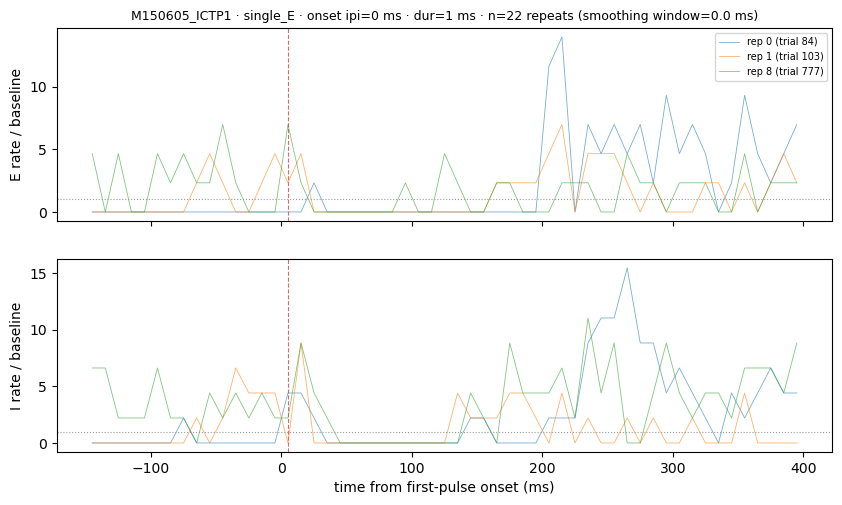

In [128]:
plot_repeats([0, 1, 8], smooth_ms=0.0, plot_mean=False)

array([<Axes: title={'center': 'M150605_ICTP1 · single_E · onset ipi=0 ms · dur=1 ms · n=22 repeats (smoothing window=0.0 ms)'}, ylabel='E rate / baseline'>,
       <Axes: xlabel='time from first-pulse onset (ms)', ylabel='I rate / baseline'>],
      dtype=object)

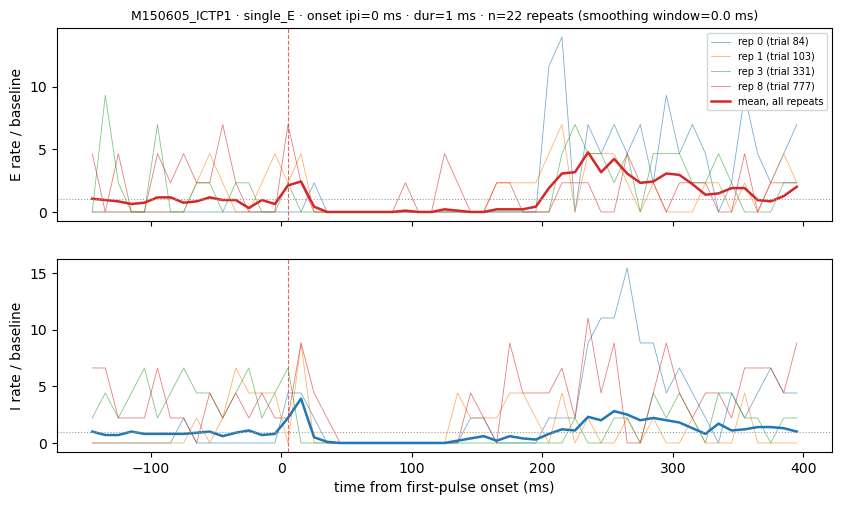

In [119]:
plot_repeats([0, 1, 3, 8], smooth_ms=0.0, causal_gauss_kernel=True)

## All repeats at once: raster-style heatmap (rows in recording order)

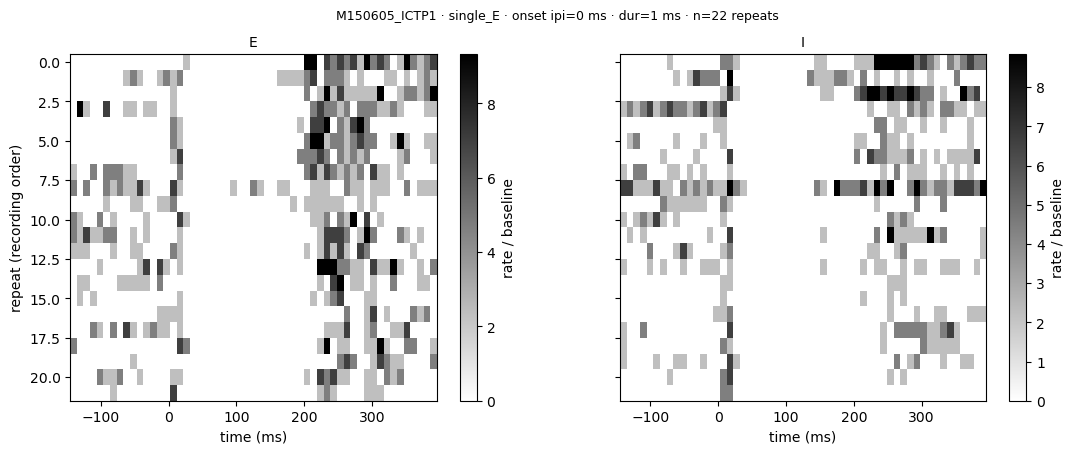

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ch, ax in enumerate(axes):
    vmax = np.percentile(Y[:, :, ch], 99)    
    im = ax.imshow(Y[:, :, ch], aspect="auto", cmap='gray_r', vmin=0, vmax=vmax,
                   extent=(time_ms[0], time_ms[-1], len(sel) - 0.5, -0.5), interpolation="nearest")
    ax.set_title(f"{'EI'[ch]}", fontsize=10)
    ax.set_xlabel("time (ms)")
    fig.colorbar(im, ax=ax, label="rate / baseline")
axes[0].set_ylabel("repeat (recording order)")
fig.suptitle(label, fontsize=9);

## Mean ± SD / SEM across repeats

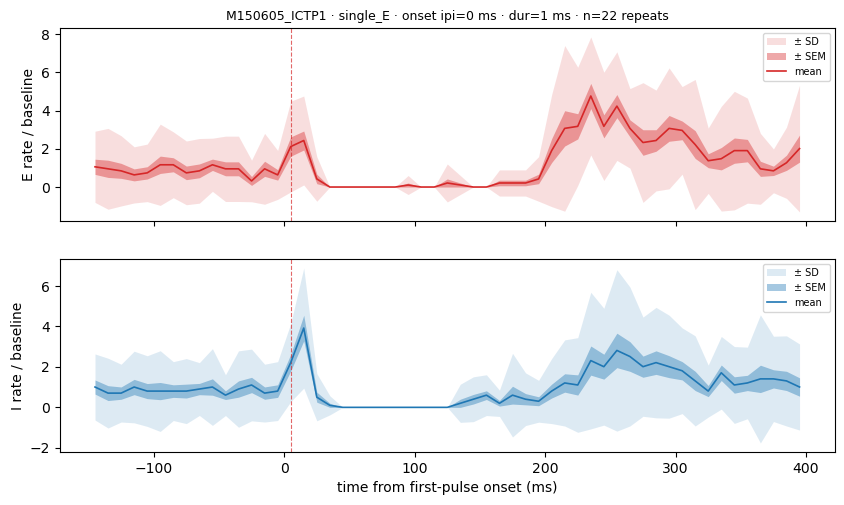

In [121]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for ch, (ax, col) in enumerate(zip(axes, ("tab:red", "tab:blue"))):
    m, sd = Y[:, :, ch].mean(0), Y[:, :, ch].std(0, ddof=1)
    sem = sd / np.sqrt(len(sel))
    shade_stim(ax)
    ax.fill_between(time_ms, m - sd, m + sd, color=col, alpha=0.15, lw=0, label="± SD")
    ax.fill_between(time_ms, m - sem, m + sem, color=col, alpha=0.4, lw=0, label="± SEM")
    ax.plot(time_ms, m, color=col, lw=1.2, label="mean")
    ax.set_ylabel(f"{'EI'[ch]} rate / baseline")
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_title(label, fontsize=9)
axes[-1].set_xlabel("time from first-pulse onset (ms)");

## Drift across the session? Per-repeat response in a window vs recording order

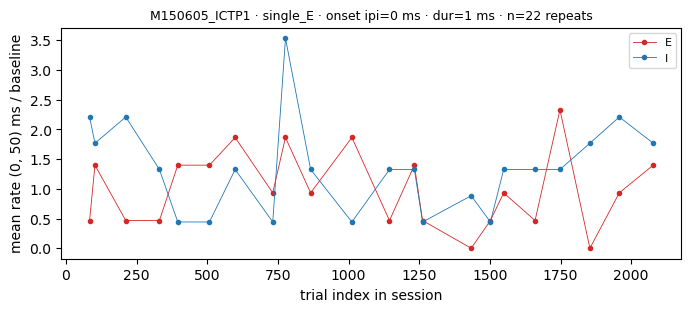

In [122]:
WIN_MS = (0, 50)    # response window
win = (time_ms >= WIN_MS[0]) & (time_ms < WIN_MS[1])
fig, ax = plt.subplots(figsize=(8, 3))
for ch, col in ((0, "tab:red"), (1, "tab:blue")):
    ax.plot(rep.trial, Y[:, win, ch].mean(1), "o-", color=col, ms=3, lw=0.6, label="EI"[ch])
ax.set_xlabel("trial index in session"); ax.set_ylabel(f"mean rate {WIN_MS} ms / baseline")
ax.legend(fontsize=8); ax.set_title(label, fontsize=9);

## Drift across the session, every trial
Same idea, but over **all** trials of the mouse (every experiment type and condition), so the trend is
dense enough to see. Pre-stimulus window: no pulse yet, so trials are comparable across conditions
and show changes in baseline excitability. Response window: depends on the condition, so expect
more scatter. Line = running mean over `RUN_N` consecutive trials (viewing only); selected repeats in black.

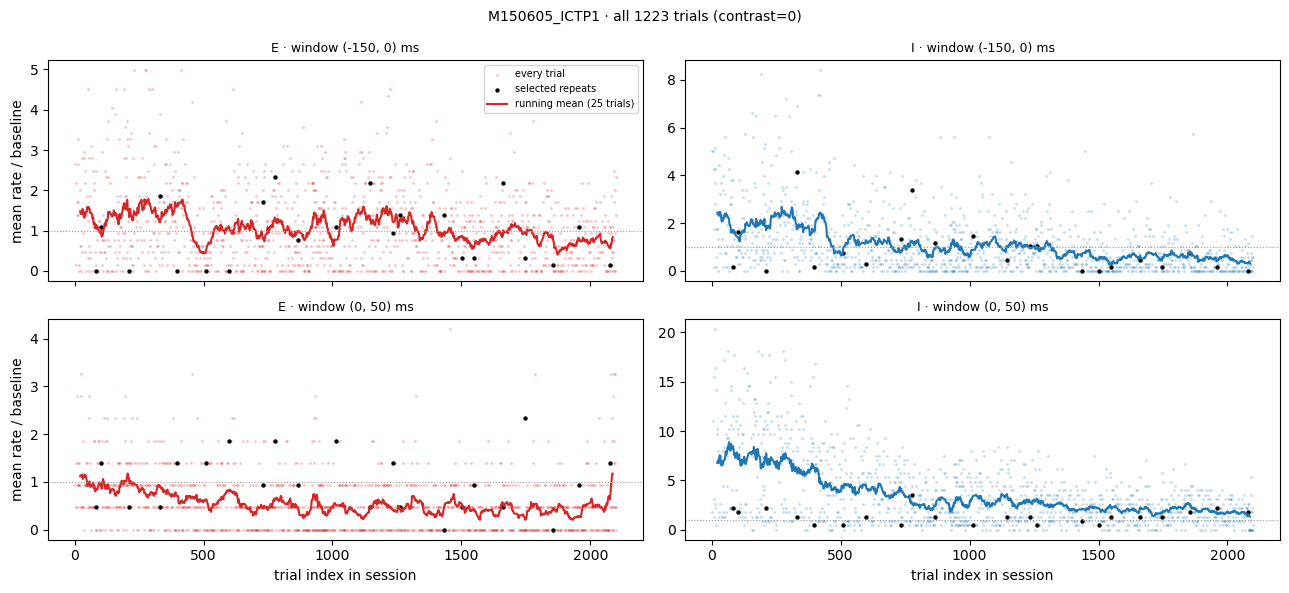

In [123]:
PRE_MS = (-150, 0)   # pre-stimulus window (CHOP starts at -150 ms)
RUN_N = 25           # trials per running-mean window

order = np.argsort(trials.trial.values)          # recording order
trial_no = trials.trial.values[order]
is_sel = np.isin(order, sel)
k = np.ones(RUN_N) / RUN_N
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for r, wms in enumerate((PRE_MS, WIN_MS)):
    w = (time_ms >= wms[0]) & (time_ms < wms[1])
    for ch, col in ((0, "tab:red"), (1, "tab:blue")):
        ax = axes[r, ch]
        v = Y_all[order][:, w, ch].mean(1)       # (N,) per-trial mean in window
        ax.scatter(trial_no, v, s=4, color=col, alpha=0.25, lw=0, label="every trial")
        ax.scatter(trial_no[is_sel], v[is_sel], s=10, color="k", lw=0, label="selected repeats")
        ax.plot(trial_no[RUN_N // 2: RUN_N // 2 + v.size - RUN_N + 1], np.convolve(v, k, mode="valid"),
                color=col, lw=1.5, label=f"running mean ({RUN_N} trials)")
        ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
        ax.set_title(f"{'EI'[ch]} · window {wms} ms", fontsize=9)
        if ch == 0:
            ax.set_ylabel("mean rate / baseline")
        if r == 1:
            ax.set_xlabel("trial index in session")
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"{ANIMAL} · all {len(trials)} trials (contrast={CONTRAST})", fontsize=10)
fig.tight_layout();

Question - what can we really learn from single-trial data?
Ideally, we don't average across trials at all. There is a scientific reason behind this choice. There sufficient differences across trials such that some of the factors that we want to pick up in our dynamical model is the trial-to-trial variability. 

However, when we use single-trial data with a small bin size (1ms), the spike rates look highly discontinuous. And it looks impossible to learn a rate network from this data alone.
Smoothing might help. O